# From FODO ring to pyLOCO

## 0. Learning objective

We will use the familiar Accelerator Toolbox FODO ring to learn the smallest useful pyLOCO workflow.

- `model` is the ideal FODO lattice.
- `machine` is a deep copy containing one known quadrupole error.
- The ORM calculated from `machine` is treated as a simulated measurement.
- pyLOCO starts from `model` and fits only that one quadrupole strength.
- Finally, we apply the opposite fitted error to `machine` and verify the correction.

Throughout the notebook:

$$R_{model}=\mathrm{ORM}(model),\qquad R_{measured}=\mathrm{ORM}(machine),$$

$$\Delta R=R_{measured}-R_{model}.$$

This notebook uses the standard **numerical** pyLOCO workflow. Analytical Jacobians are deliberately left for the next exercise.

## 1. Imports

In [58]:
%matplotlib inline

import copy
from tempfile import TemporaryDirectory

import at
import matplotlib.pyplot as plt
import numpy as np

from pyLOCO.analysis import plot_matrices
from pyLOCO.config import FitInitConfig, RMConfig
from pyLOCO.pyloco import pyloco
from pyLOCO.response_matrix import response_matrix

## 2. Build the familiar AT FODO lattice

The magnet sequence and parameters below are adapted from the official [Accelerator Toolbox pyAT Primer FODO example](https://atcollab.github.io/at/p/notebooks/ATPrimer.html): two 0.5 m quadrupoles with $K=\pm1.2\,\mathrm{m}^{-2}$, two 1 m bends per cell, and twenty cells.

For LOCO we add only zero-length BPMs and horizontal/vertical correctors near the quadrupoles. We do not add RF, sextupoles, coupling, calibration errors, alignment errors, or noise.

In [59]:
QF = at.Quadrupole('QF', 0.5, 1.2)
QD = at.Quadrupole('QD', 0.5, -1.2)
Dr = at.Drift('Dr', 0.5)
HalfDr = at.Drift('Dr', 0.25)
Bend = at.Dipole('Bend', 1.0, 2 * np.pi / 40)

BPM_F = at.Monitor('BPM_F')
BPM_D = at.Monitor('BPM_D')
HCOR_F = at.Corrector('HCOR_F', 0.0, [0.0, 0.0])
HCOR_D = at.Corrector('HCOR_D', 0.0, [0.0, 0.0])
VCOR_F = at.Corrector('VCOR_F', 0.0, [0.0, 0.0])
VCOR_D = at.Corrector('VCOR_D', 0.0, [0.0, 0.0])

FODOcell = at.Lattice(
    [HalfDr, Bend, Dr, BPM_F, HCOR_F, VCOR_F, QF,
     Dr, Bend, Dr, BPM_D, HCOR_D, VCOR_D, QD, HalfDr],
    name='Simple FODO cell with diagnostics',
    energy=1e9,
)

model = FODOcell * 20
at.fit_tune(model, QF, QD, [0.15, 0.75])
model.name = 'Simple FODO ring for pyLOCO'
model.disable_6d()


Fitting Tune...
Initial value [0.21993568 0.91777806]
iter# 0 Res. 0.4124111606069367
iter# 1 Res. 0.1917758804555535
iter# 2 Res. 0.4221394172477185
Final value [0.03176851 0.11112542] 



In [60]:
bpm_indices = np.asarray(at.get_refpts(model, at.Monitor), dtype=int)
hcor_indices = np.asarray(at.get_refpts(model, 'HCOR*'), dtype=int)
vcor_indices = np.asarray(at.get_refpts(model, 'VCOR*'), dtype=int)
quad_indices = np.asarray(at.get_refpts(model, at.Quadrupole), dtype=int)

print(f'Elements:              {len(model)}')
print(f'BPMs:                  {len(bpm_indices)}')
print(f'Horizontal correctors: {len(hcor_indices)}')
print(f'Vertical correctors:   {len(vcor_indices)}')
print(f'Quadrupoles:           {len(quad_indices)}')

Elements:              300
BPMs:                  40
Horizontal correctors: 40
Vertical correctors:   40
Quadrupoles:           40


## 3. Inspect the nominal optics

Only the optics needed later are shown. The ring must have finite, stable tunes before an ORM or LOCO fit is meaningful.

Nominal tune: Qx=0.031769, Qy=0.111125


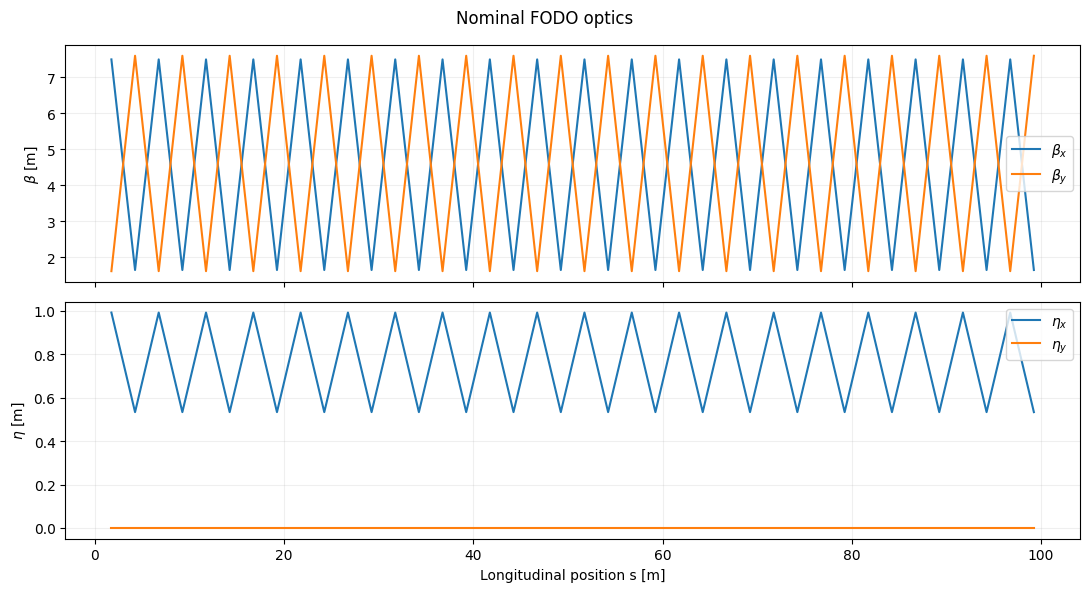

In [61]:
all_refpts = at.get_refpts(model, at.elements.Monitor)
_, _, optics_model = at.get_optics(model, all_refpts)
tune_model = np.asarray(at.get_tune(model))
print(f'Nominal tune: Qx={tune_model[0]:.6f}, Qy={tune_model[1]:.6f}')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(optics_model.s_pos, optics_model.beta[:, 0], label=r'$\beta_x$')
axes[0].plot(optics_model.s_pos, optics_model.beta[:, 1], label=r'$\beta_y$')
axes[0].set_ylabel(r'$\beta$ [m]')
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[1].plot(optics_model.s_pos, optics_model.dispersion[:, 0], label=r'$\eta_x$')
axes[1].plot(optics_model.s_pos, optics_model.dispersion[:, 2], label=r'$\eta_y$')
axes[1].set(xlabel='Longitudinal position s [m]', ylabel=r'$\eta$ [m]')
axes[1].legend(); axes[1].grid(alpha=0.2)
fig.suptitle('Nominal FODO optics'); fig.tight_layout(); plt.show()

## 4. Configure the ORM calculation using pyLOCO

`pyLOCO.response_matrix()` offers two useful ORM calculation modes:

- `calculator='Linear'` uses linear transfer matrices. It is fast and is the current default.
- `calculator='Tracking'` applies corrector kicks and recalculates the closed orbit numerically. In the current implementation, any value other than `Linear` selects this numerical branch; `Tracking` makes the intention clear.

Change `orm_calculator` below to choose the method used in the tutorial. We calculate both once so their agreement can be checked.

We use a $10\,\mu\mathrm{rad}=10^{-5}\,\mathrm{rad}$ kick. The returned matrix contains orbit displacement in metres for that kick, which is the form fitted and plotted by pyLOCO. Divide by the kick only when a normalized value in $\mathrm{m/rad}$ is needed.

In [62]:
corrector_kick_rad = 10e-6  # rad
kick_steps = [
    [corrector_kick_rad] * len(hcor_indices),
    [corrector_kick_rad] * len(vcor_indices),
]
orm_calculator = 'Linear'  # Change to 'Tracking' for numerical closed-orbit tracking

def make_rm_config(calculator):
    return RMConfig(
        bpm_ords=bpm_indices,
        cm_ords=[hcor_indices, vcor_indices],
        dkick=kick_steps,
        calculator=calculator,
        bidirectional=True,
        includeDispersion=False,
        fixedpathlength=False,
        HCMCoupling=np.zeros(len(hcor_indices)),
        VCMCoupling=np.zeros(len(vcor_indices)),
    )

rm_config_linear = make_rm_config('Linear')
rm_config_tracking = make_rm_config('Tracking')
rm_config = make_rm_config(orm_calculator)

## 5. Generate the model ORM

In [63]:
R_model_linear = response_matrix(model, config=rm_config_linear)
R_model_tracking = response_matrix(model, config=rm_config_tracking)
R_model = R_model_linear if orm_calculator == 'Linear' else R_model_tracking
orm_method_rms = float(np.sqrt(np.mean((R_model_tracking - R_model_linear)**2)))
print(f'Active ORM calculator: {orm_calculator}')
print(f'Linear versus tracking RMS difference: {orm_method_rms:.6e} m')
n_bpm = len(bpm_indices)
n_hcor = len(hcor_indices)
Rxx = R_model[:n_bpm, :n_hcor]
Rxy = R_model[:n_bpm, n_hcor:]
Ryx = R_model[n_bpm:, :n_hcor]
Ryy = R_model[n_bpm:, n_hcor:]

print('R_model shape:', R_model.shape)
print('Rows: horizontal BPMs, then vertical BPMs')
print('Columns: horizontal correctors, then vertical correctors')
print(f'Maximum cross-plane response: {max(np.max(np.abs(Rxy)), np.max(np.abs(Ryx))):.3e} m')

Active ORM calculator: Linear
Linear versus tracking RMS difference: 2.456082e-18 m
R_model shape: (80, 80)
Rows: horizontal BPMs, then vertical BPMs
Columns: horizontal correctors, then vertical correctors
Maximum cross-plane response: 0.000e+00 m


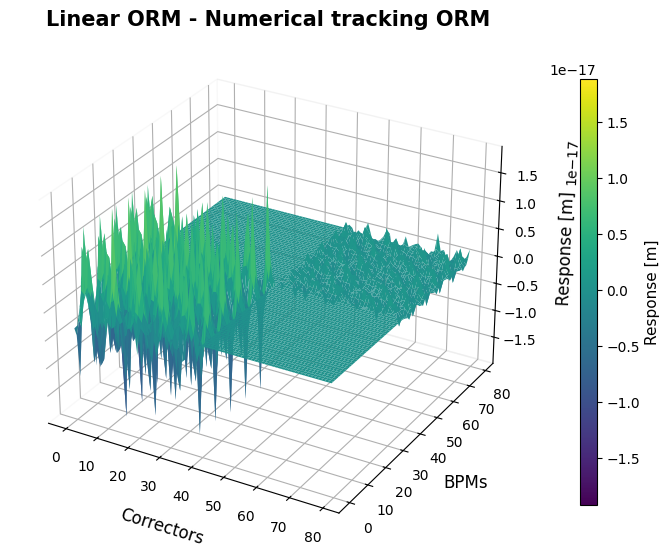

In [78]:
plot_matrices(
    R_model_linear- R_model_tracking,
    titles=['Linear ORM - Numerical tracking ORM'],
    cmap='viridis', plot_type='3d', same_scale=True,
)
R_model_normalized = R_model / corrector_kick_rad

## 6. Create the simulated machine

We make a deep copy so the ideal `model` remains unchanged. The selected focusing quadrupole receives a known $+1\%$ strength error.

The **machine error** is $\Delta K_{true}=K_{machine}-K_{model}$. The correction required later has the opposite sign.

In [79]:
machine = copy.deepcopy(model)
target_quad_index = int(quad_indices[10])  # a QF in the sixth FODO cell
relative_error = 0.01
K_model = float(model[target_quad_index].K)
K_machine = K_model * (1.0 + relative_error)
machine[target_quad_index].K = K_machine
machine[target_quad_index].PolynomB[1] = K_machine
true_delta_K = K_machine - K_model

print(f'Quadrupole index: {target_quad_index}')
print(f'Quadrupole name:  {model[target_quad_index].FamName}')
print(f'Nominal K:        {K_model:+.9e} m^-2')
print(f'Machine K:        {K_machine:+.9e} m^-2')
print(f'True ΔK:          {true_delta_K:+.9e} m^-2')
print(f'True ΔK/K:        {100*true_delta_K/K_model:+.6f} %')

Quadrupole index: 81
Quadrupole name:  QF
Nominal K:        +1.174684048e+00 m^-2
Machine K:        +1.186430888e+00 m^-2
True ΔK:          +1.174684048e-02 m^-2
True ΔK/K:        +1.000000 %


## 7. Observe the optics error

A quadrupole error changes the focusing, which changes the tune, beta functions, dispersion, and therefore the ORM.

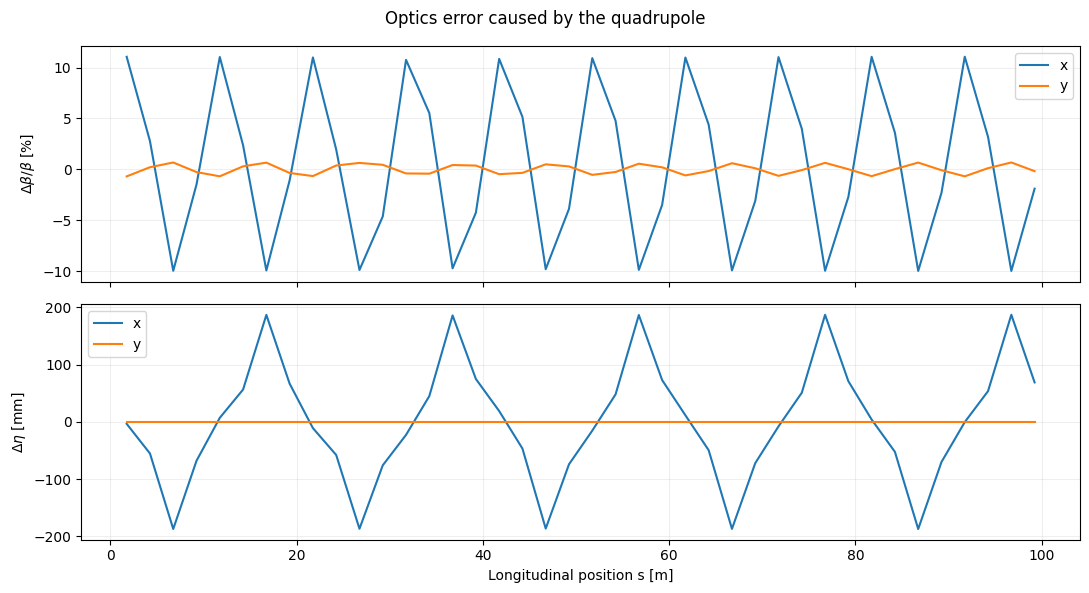

In [80]:
_, _, optics_machine = at.get_optics(machine, all_refpts)
tune_machine = np.asarray(at.get_tune(machine))
beta_beating_machine = (optics_machine.beta - optics_model.beta) / optics_model.beta
dispersion_error_machine = optics_machine.dispersion - optics_model.dispersion

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(optics_model.s_pos, 100*beta_beating_machine[:, 0], label='x')
axes[0].plot(optics_model.s_pos, 100*beta_beating_machine[:, 1], label='y')
axes[0].set_ylabel(r'$\Delta\beta/\beta$ [%]')
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[1].plot(optics_model.s_pos, 1e3*dispersion_error_machine[:, 0], label='x')
axes[1].plot(optics_model.s_pos, 1e3*dispersion_error_machine[:, 2], label='y')
axes[1].set(xlabel='Longitudinal position s [m]', ylabel=r'$\Delta\eta$ [mm]')
axes[1].legend(); axes[1].grid(alpha=0.2)
fig.suptitle('Optics error caused by the quadrupole'); fig.tight_layout(); plt.show()

## 8. Generate the simulated measured ORM

The same BPM indices, corrector indices, kick amplitudes, and row/column ordering are used for both lattices. In a real experiment `R_measured` would come from the accelerator; here it comes from the copied lattice with a known error, so we know the correct answer.

In [81]:
R_measured = response_matrix(machine, config=rm_config)
delta_R = R_measured - R_model
delta_R_rms_m = float(np.sqrt(np.mean(delta_R**2)))
delta_R_normalized = delta_R / corrector_kick_rad
delta_R_rms_m_per_rad = float(np.sqrt(np.mean(delta_R_normalized**2)))
print(f'ORM displacement RMS difference: {delta_R_rms_m:.6e} m')
print(f'Normalized ORM RMS difference:   {delta_R_rms_m_per_rad:.6e} m/rad')

ORM displacement RMS difference: 1.083494e-05 m
Normalized ORM RMS difference:   1.083494e+00 m/rad


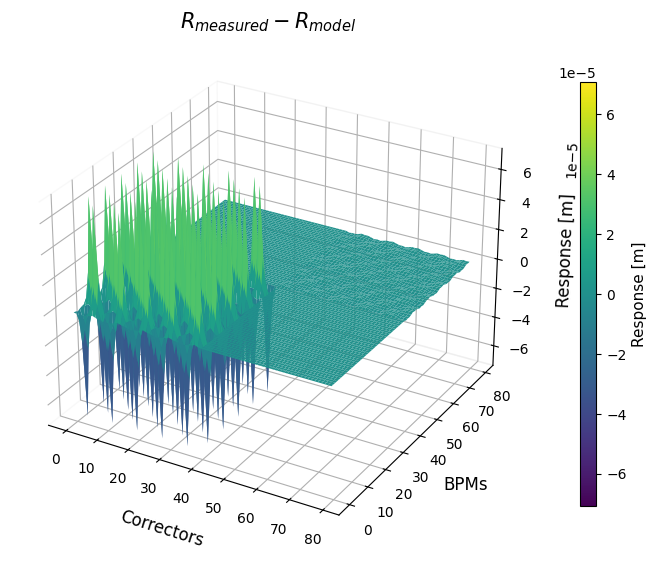

In [82]:
plot_matrices(
    delta_R,
    titles=[r'$R_{measured}-R_{model}$'],
     plot_type='3d',
)

## 9. Jacobian calculation from the previous student task

Current pyLOCO fits the absolute quadrupole strength stored in `PolynomB[1]`, which is $K$ in $\mathrm{m}^{-2}$. It does not use $KL$, relative $K$, or $\Delta KL$ here.

As in the previous student task, calculate the ORM sensitivity with a **central finite difference**:

$$J=\frac{\partial R}{\partial K}\approx\frac{R(K+\delta K)-R(K-\delta K)}{2\delta K}.$$

Calculate both perturbed ORMs, flatten the sensitivity matrix into one column in Fortran order, and solve $J\,\Delta K\simeq\Delta R$ with `np.linalg.lstsq`. This reproduces the workflow the student already learned before introducing pyLOCO's iterative fit.

Current pyLOCO internally uses a forward finite difference for its normal-quadrupole Jacobian. Both formulas approximate the same derivative, but the student-facing calculation below deliberately uses the previously taught central formula. Later, an analytical formula can become a third Jacobian method. ORM calculation (`Linear` or numerical closed-orbit calculation) is a separate choice from Jacobian calculation (central, forward, or analytical).

In [83]:
delta_K_jacobian = 1e-3 * abs(K_model)  # m^-2
ring_K_plus = copy.deepcopy(model)
ring_K_minus = copy.deepcopy(model)
for ring, strength in ((ring_K_plus, K_model + delta_K_jacobian),
                       (ring_K_minus, K_model - delta_K_jacobian)):
    ring[target_quad_index].K = strength
    ring[target_quad_index].PolynomB[1] = strength

R_K_plus_delta = response_matrix(ring_K_plus, config=rm_config)
R_K_minus_delta = response_matrix(ring_K_minus, config=rm_config)
J_matrix = (R_K_plus_delta - R_K_minus_delta) / (2 * delta_K_jacobian)
J_column = J_matrix.reshape(-1, order='F')[:, np.newaxis]
delta_R_column = delta_R.reshape(-1, order='F')[:, np.newaxis]
delta_K_manual = float(np.linalg.lstsq(J_column, delta_R_column, rcond=None)[0][0, 0])

print(f'Central finite-difference step: {delta_K_jacobian:.6e} m^-2')
print('One ORM sensitivity matrix:', J_matrix.shape)
print('One flattened Jacobian column:', J_column.shape)
print('Units of this Jacobian: m per (m^-2), for the configured corrector kick')
print(f'Manual least-squares ΔK: {delta_K_manual:+.9e} m^-2')
print(f'True assigned ΔK:       {true_delta_K:+.9e} m^-2')
print(f'One-step difference:    {100*(delta_K_manual/true_delta_K - 1):+.6f} %')

Central finite-difference step: 1.174684e-03 m^-2
One ORM sensitivity matrix: (80, 80)
One flattened Jacobian column: (6400, 1)
Units of this Jacobian: m per (m^-2), for the configured corrector kick
Manual least-squares ΔK: +9.535802564e-03 m^-2
True assigned ΔK:       +1.174684048e-02 m^-2
One-step difference:    -18.822405 %


## 10. Minimal pyLOCO configuration

`RMConfig` above describes how to calculate an ORM. `FitInitConfig` below tells pyLOCO that the only fit block is `quads`, that quadrupoles are individual parameters, and that their value is read from `PolynomB[1]`.

Only `target_quad_index` is passed to `quads_ords`, so the fit contains exactly one unknown. The equal weights do not add noise; they simply give every ORM row equal importance in the least-squares objective.

In [85]:
fitted_quad_indices = np.asarray([target_quad_index], dtype=int)
fit_config = FitInitConfig(
    fit_list=['quads'],
    CMstep=kick_steps,
    individuals=True,
    quads_attr='PolynomB',
    quads_attr_index=1,
)
equal_weights = np.ones(2 * n_bpm)

## 11. Run the LOCO fit

The manual central-difference result above is one linearized least-squares step, so it need not recover a finite 1% error exactly. pyLOCO repeats the fit around the updated model. It builds its internal forward-difference Jacobian, flattens the ORM in Fortran order, and solves the regularized least-squares step using SVD and Levenberg–Marquardt. With one well-observed parameter, two outer iterations are sufficient. Jacobian/log files are placed in a temporary directory and removed after the fit.

At present, `pyloco()` constructs its internal ORM configuration with the default `Linear` calculator and does not expose the calculator as a fit argument. Therefore this tutorial keeps `orm_calculator='Linear'` for the actual fit. The separate comparison above demonstrates the numerical tracking option without implying that the fit has switched methods.

In [86]:
temporary_output = TemporaryDirectory(prefix='pyloco_fodo_')
try:
    fit_result = pyloco(
        copy.deepcopy(model), algorithm='lm', nIter=2,
        used_bpms_ords=bpm_indices,
        used_cor_ords=[hcor_indices, vcor_indices],
        quads_ords=fitted_quad_indices,
        skew_ords=np.array([], dtype=int),
        CAVords=np.array([], dtype=int),
        nHBPM=n_bpm, nVBPM=n_bpm,
        nHorCOR=len(hcor_indices), nVerCOR=len(vcor_indices),
        quads_tilt_ind=fitted_quad_indices,
        orm_measured=R_measured, weights=equal_weights,
        includeDispersion=False,
        measured_eta_x=np.zeros(n_bpm), measured_eta_y=np.zeros(n_bpm),
        CMstep=kick_steps, rfStep=1.0, Frequency=1.0,
        fit_list=['quads'], quad_individuals=True, remove_coupling_=True,
        outlier_rejection=False, apply_normalization=False,
        svd_selection_method='threshold', svd_threshold=1e-12,
        cut_=None, show_svd_plot=False,
        nLMIter=6, Starting_Lambda=1e-3, max_lm_lambda=15.0, scaled=True,
        plot_fit_parameters=False, auto_correct_delta=False,
        fixedpathlength=False, fixedmomentum=False,
        fit_cfg=fit_config, output_dir=temporary_output.name,
    )
finally:
    temporary_output.cleanup()

fit_parameters, fit_dictionary, fitted_model, R_fitted, _, chi2_history, _, _ = fit_result
for iteration, chi2 in enumerate(chi2_history, start=1):
    print(f'Iteration {iteration}: normalized chi-square = {chi2:.6e}')


==== Iteration 1/2 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
Normal quad Jacobian: 1.3 s
[Jacobian] Saved normal-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_fodo_sym2gvyp/jacobians/quads/J_quads_iter1_1e-05urad_-3000.0Hz.h5
Initial Chi²: 2.3487e-10
  LM inner 1: chi² 4.7689e-12 (previous 2.3487e-10), λ=0.001
Chi² after correction: 4.7689e-12

==== Iteration 2/2 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 2)...
Normal quad Jacobian: 1.3 s
Initial Chi²: 4.7689e-12
  LM inner 1: chi² 8.6938e-16 (previous 4.7689e-12), λ=0.001
Chi² after correction: 8.6938e-16
LOCO LM completed! :).
Iteration 1: normalized chi-square = 4.768867e-12
Iteration 2: normalized chi-square = 8.693837e-16


## 12. Compare the true and reconstructed error

The fitted machine error is $\Delta K_{fit}=K_{fitted}-K_{model}$. It should have the same sign as the deliberately introduced machine error. The correction to apply is $-\Delta K_{fit}$.

In [87]:
fitted_delta_K = float(fitted_model[target_quad_index].K - K_model)
delta_K_difference = fitted_delta_K - true_delta_K
relative_fitting_error_pct = 100 * delta_K_difference / true_delta_K
correction_delta_K = -fitted_delta_K
print(f'True machine error ΔK: {true_delta_K:+.9e} m^-2')
print(f'Fitted error ΔK_fit:   {fitted_delta_K:+.9e} m^-2')
print(f'Fit minus truth:       {delta_K_difference:+.9e} m^-2')
print(f'Relative fitting error:{relative_fitting_error_pct:+.6f} %')
print(f'Correction to apply:   {correction_delta_K:+.9e} m^-2')

True machine error ΔK: +1.174684048e-02 m^-2
Fitted error ΔK_fit:   +1.171902841e-02 m^-2
Fit minus truth:       -2.781207188e-05 m^-2
Relative fitting error:-0.236762 %
Correction to apply:   -1.171902841e-02 m^-2


## 13. Apply the correction

The fitted lattice returned by pyLOCO represents its reconstructed machine. To correct our simulated machine, we subtract that reconstructed error from the machine strength. Both AT representations, `K` and `PolynomB[1]`, are kept consistent.

In [88]:
corrected_machine = copy.deepcopy(machine)
K_corrected = K_machine + correction_delta_K
corrected_machine[target_quad_index].K = K_corrected
corrected_machine[target_quad_index].PolynomB[1] = K_corrected
print(f'Corrected K:             {K_corrected:+.9e} m^-2')
print(f'Remaining K-model error: {K_corrected-K_model:+.9e} m^-2')

Corrected K:             +1.174711860e+00 m^-2
Remaining K-model error: +2.781207188e-05 m^-2


## 14. Verify the correction

In [89]:
R_corrected = response_matrix(corrected_machine, config=rm_config)
_, _, optics_corrected = at.get_optics(corrected_machine, all_refpts)
tune_corrected = np.asarray(at.get_tune(corrected_machine))
beta_beating_corrected = (optics_corrected.beta - optics_model.beta) / optics_model.beta
dispersion_error_corrected = optics_corrected.dispersion - optics_model.dispersion

orm_rms_before = float(np.sqrt(np.mean(((R_measured-R_model)/corrector_kick_rad)**2)))
orm_rms_after = float(np.sqrt(np.mean(((R_corrected-R_model)/corrector_kick_rad)**2)))
beta_rms_before = 100*np.sqrt(np.mean(beta_beating_machine**2, axis=0))
beta_rms_after = 100*np.sqrt(np.mean(beta_beating_corrected**2, axis=0))

print(f'Normalized ORM RMS before: {orm_rms_before:.6e} m/rad')
print(f'Normalized ORM RMS after:  {orm_rms_after:.6e} m/rad')
print(f'Beta-x beating RMS: {beta_rms_before[0]:.6f}% -> {beta_rms_after[0]:.6f}%')
print(f'Beta-y beating RMS: {beta_rms_before[1]:.6f}% -> {beta_rms_after[1]:.6f}%')
print('Tunes [Qx, Qy]:')
print('  model:    ', tune_model)
print('  machine:  ', tune_machine)
print('  corrected:', tune_corrected)

Normalized ORM RMS before: 1.083494e+00 m/rad
Normalized ORM RMS after:  3.156668e-03 m/rad
Beta-x beating RMS: 7.795847% -> 0.020416%
Beta-y beating RMS: 0.469680% -> 0.001105%
Tunes [Qx, Qy]:
  model:     [0.03176851 0.11112542]
  machine:   [0.03525793 0.11041417]
  corrected: [0.03177722 0.11112374]


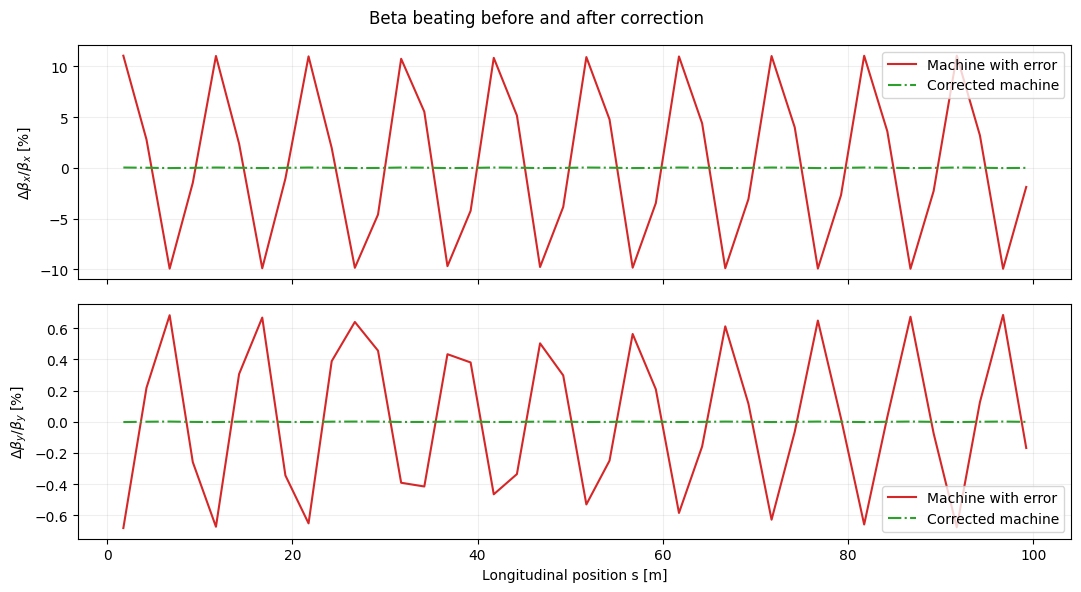

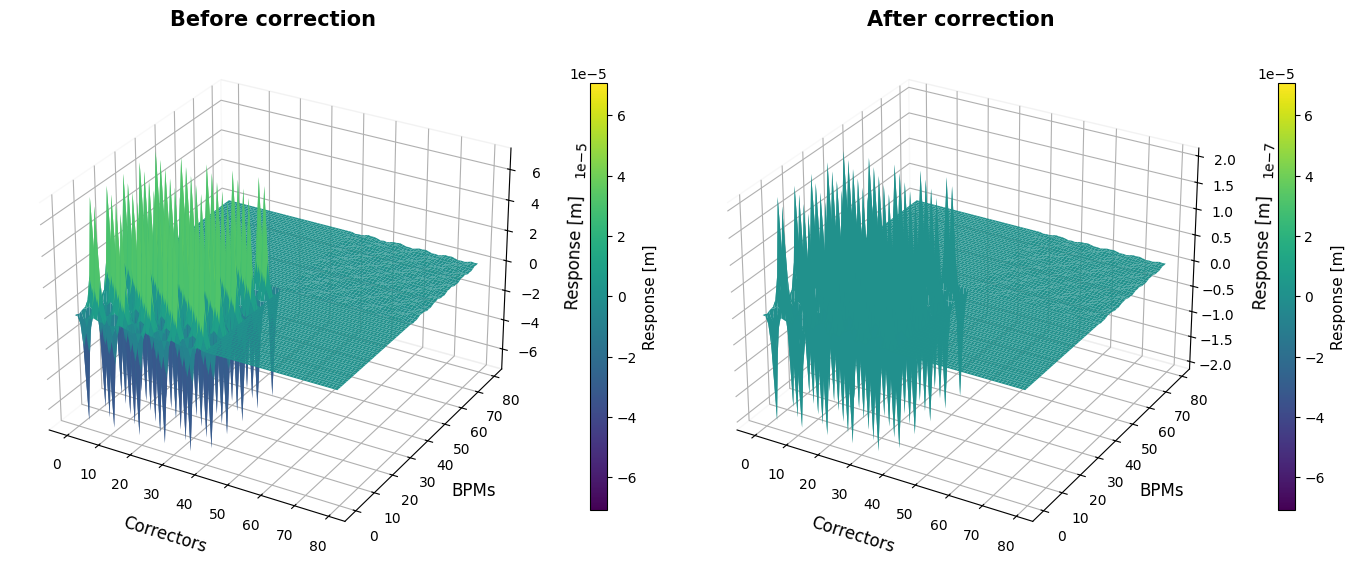

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for plane, label in enumerate(('x', 'y')):
    axes[plane].plot(optics_model.s_pos, 100*beta_beating_machine[:, plane],
                     color='C3', label='Machine with error')
    axes[plane].plot(optics_model.s_pos, 100*beta_beating_corrected[:, plane],
                     color='C2', linestyle='-.', label='Corrected machine')
    axes[plane].set_ylabel(rf'$\Delta\beta_{label}/\beta_{label}$ [%]')
    axes[plane].grid(alpha=0.2); axes[plane].legend()
axes[-1].set_xlabel('Longitudinal position s [m]')
fig.suptitle('Beta beating before and after correction'); fig.tight_layout(); plt.show()

corrected_delta_R = R_corrected - R_model
plot_matrices(
    delta_R, corrected_delta_R,
    titles=['Before correction', 'After correction'],
    plot_type='3d', same_scale=True,
)

## 15. Final summary

In [90]:
print('FODO one-quadrupole pyLOCO summary')
print('-' * 64)
print(f'True ΔK [m^-2]                    {true_delta_K:+.9e}')
print(f'Fitted ΔK [m^-2]                  {fitted_delta_K:+.9e}')
print(f'Relative ΔK fitting error [%]      {relative_fitting_error_pct:+.6f}')
print(f'ORM RMS before [m/rad]             {orm_rms_before:.9e}')
print(f'ORM RMS after correction [m/rad]   {orm_rms_after:.9e}')
print(f'Beta-x RMS before/after [%]         {beta_rms_before[0]:.6f} / {beta_rms_after[0]:.6f}')
print(f'Beta-y RMS before/after [%]         {beta_rms_before[1]:.6f} / {beta_rms_after[1]:.6f}')
print(f'Qx model/machine/corrected          {tune_model[0]:.8f} / {tune_machine[0]:.8f} / {tune_corrected[0]:.8f}')
print(f'Qy model/machine/corrected          {tune_model[1]:.8f} / {tune_machine[1]:.8f} / {tune_corrected[1]:.8f}')
print(f'LOCO outer iterations              {len(chi2_history)}')

FODO one-quadrupole pyLOCO summary
----------------------------------------------------------------
True ΔK [m^-2]                    +1.174684048e-02
Fitted ΔK [m^-2]                  +1.171902841e-02
Relative ΔK fitting error [%]      -0.236762
ORM RMS before [m/rad]             1.083494091e+00
ORM RMS after correction [m/rad]   3.156667860e-03
Beta-x RMS before/after [%]         7.795847 / 0.020416
Beta-y RMS before/after [%]         0.469680 / 0.001105
Qx model/machine/corrected          0.03176851 / 0.03525793 / 0.03177722
Qy model/machine/corrected          0.11112542 / 0.11041417 / 0.11112374
LOCO outer iterations              2


## 16. Questions for the student

1. Why does changing a quadrupole strength change the ORM?
2. What is the difference between `R_model` and `R_measured` in this simulation?
3. What does one column of the Jacobian represent physically?
5. What quantity is pyLOCO minimizing?
6. Why should $\Delta K_{fit}$ agree with the deliberately introduced $\Delta K$?
7. What is the difference between the fitted machine error and the correction that should be applied?
8. Why does correcting the quadrupole also reduce beta beating?
9. What would change if two or more quadrupoles had unknown errors?
10. Why does a numerical Jacobian become computationally expensive for a real accelerator with hundreds of fitted parameters?

The final question motivates the next, separate exercise: comparing numerical and analytical Jacobians.